In [26]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from numpy.typing import NDArray


In [27]:
MAIN_FOLDER = Path("/home/arman/it/AI_work/sound")
DATASET_FOLDER = MAIN_FOLDER / "dataset"
RESULTS_FOLDER = MAIN_FOLDER / "results"

audio_files = sorted(DATASET_FOLDER.glob("*"))
AUDIO_PATH = audio_files[0]
print(AUDIO_PATH)


/home/arman/it/AI_work/sound/dataset/kish_durak_i_molniya.mp3


In [28]:
class MyAudio:
    audio: NDArray[np.float32]
    sample_rate: int

    def __init__(self) -> None:
        self.audio = np.array([], dtype=np.float32)
        self.sample_rate = 0

    def load_audio(self, audio_path: str | Path) -> None:
        self.audio, self.sample_rate = librosa.load(audio_path, sr=None)

    def save_audio(self, output_name: str) -> None:
        output_path = RESULTS_FOLDER / output_name
        sf.write(output_path, self.audio, self.sample_rate)

    def set_audio_fragment(self, start_time: float, end_time: float) -> None:
        start_index = int(start_time * self.sample_rate)
        end_index = int(end_time * self.sample_rate)
        self.audio = self.audio[start_index:end_index].copy()

    def change_sample_rate(self, target_sample_rate: int) -> None:
        self.sample_rate = target_sample_rate

    def resample_audio(self, target_sample_rate: int) -> None:
        self.audio = librosa.resample(
            self.audio,
            orig_sr=self.sample_rate,
            target_sr=target_sample_rate,
        )
        self.sample_rate = target_sample_rate

    def build_spectrogram(self) -> None:
        spectrogram = np.abs(librosa.stft(self.audio))
        spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

        plt.figure(figsize=(12, 6))
        librosa.display.specshow(spectrogram_db, sr=self.sample_rate, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title("spectrogram")
        plt.tight_layout()
        plt.show()

    def build_waveform(self) -> None:
        plt.figure(figsize=(12, 4))
        librosa.display.waveshow(self.audio, sr=self.sample_rate)
        plt.title("waveform")
        plt.xlabel("time")
        plt.ylabel("amplitude")
        plt.tight_layout()
        plt.show()

    def build_mfcc(self) -> None:
        mfcc = librosa.feature.mfcc(y=self.audio, sr=self.sample_rate, n_mfcc=13)

        plt.figure(figsize=(12, 6))
        librosa.display.specshow(mfcc, x_axis="time", sr=self.sample_rate)
        plt.colorbar()
        plt.title("mfcc")
        plt.tight_layout()
        plt.show()

    def build_chroma(self) -> None:
        chroma = librosa.feature.chroma_stft(y=self.audio, sr=self.sample_rate)

        plt.figure(figsize=(12, 6))
        librosa.display.specshow(chroma, x_axis="time", y_axis="chroma", sr=self.sample_rate)
        plt.colorbar()
        plt.title("chroma")
        plt.tight_layout()
        plt.show()


In [29]:
kish = MyAudio()
kish.load_audio(AUDIO_PATH)


In [30]:
kish.set_audio_fragment(0, 5)

In [31]:
kish.save_audio("cut.wav")
kish.audio.shape, kish.sample_rate


((220500,), 44100)

In [32]:
kish.change_sample_rate(22050)
kish.save_audio("change_sample_rate.wav")
kish.audio.shape, kish.sample_rate


((220500,), 22050)

In [33]:
kish.change_sample_rate(44100)

In [34]:
kish.resample_audio(16000)
kish.save_audio("resample.wav")
kish.audio.shape, kish.sample_rate


((80000,), 16000)

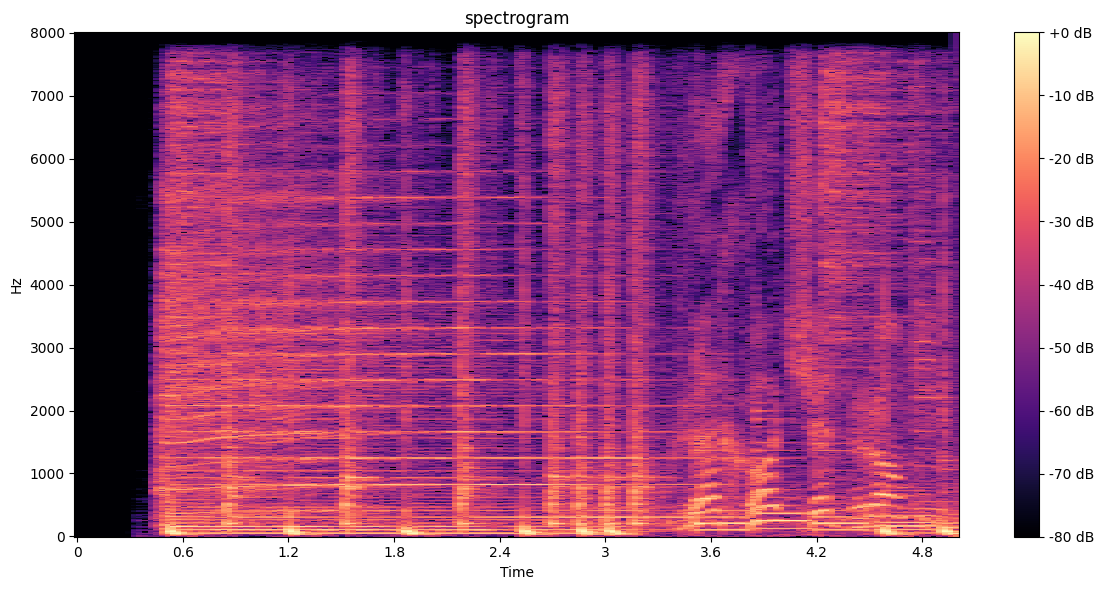

In [35]:
kish.build_spectrogram()


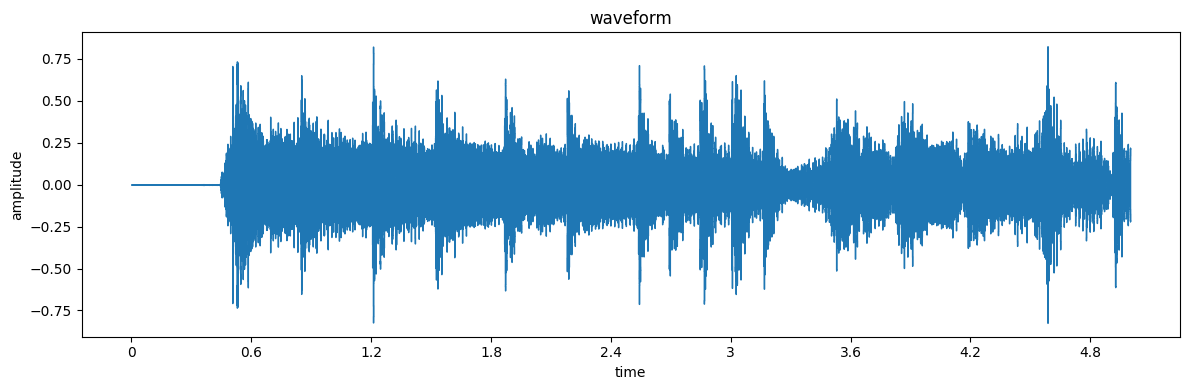

In [36]:
kish.build_waveform()


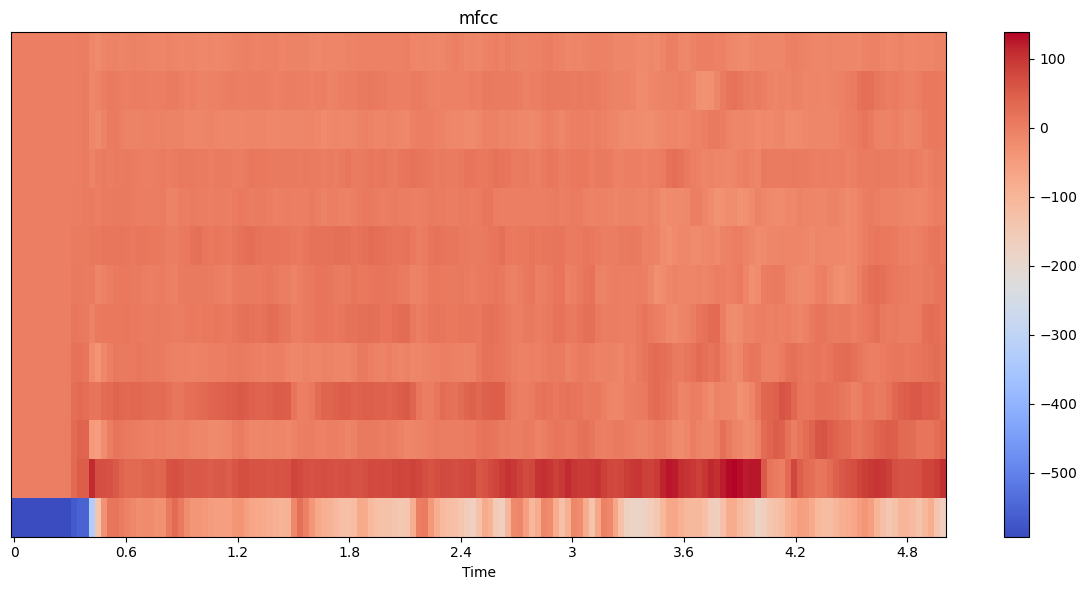

In [37]:
kish.build_mfcc()


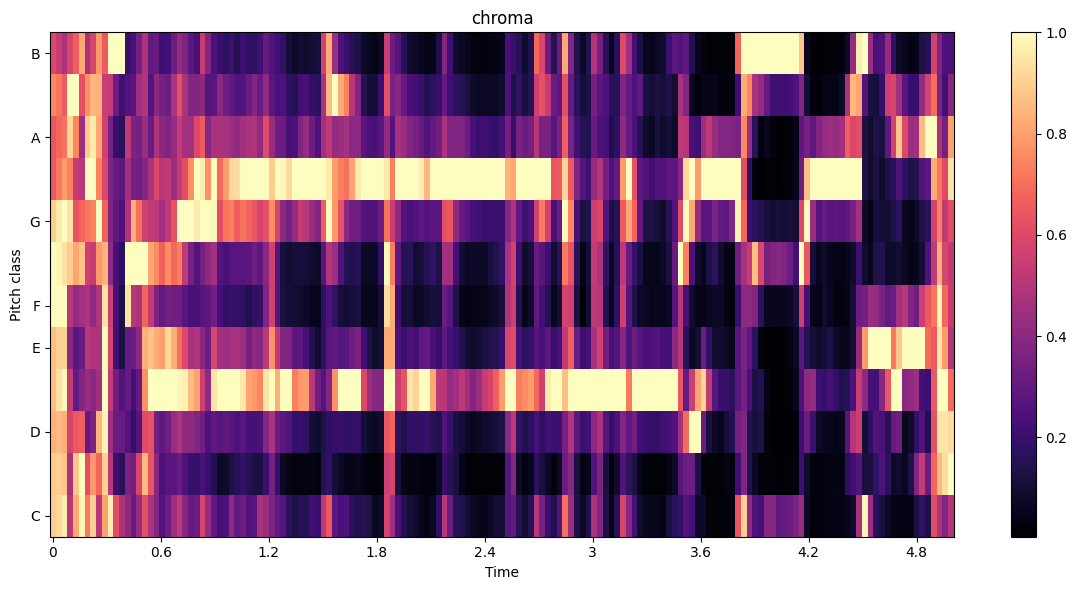

In [38]:
kish.build_chroma()
